# n → ∞ 极限下 B_Omega 算法行为测试

**核心问题**：score ≈ 150 是 sampling noise 造成的，还是算法本身的 local minima？

**方法**：用理论协方差 `S_pop = (I-B*^T)^{-1} Ω* (I-B*)^{-1}` 代替样本协方差（等价于 n → ∞）。

**算法**：`dag_coordinate_descent_BOmega`（随机顺序）和 `dag_coordinate_descent_BOmega_epoch`（epoch）

**参数**：λ ∈ {0, 0.1, 0.2}，每组 100 次随机初始化（seed=0..99）

## Step 0: Imports & Setup

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.append(r"C:\Users\super\DAG")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from MEC import is_in_markov_equiv_class
from coordinate_descent.cd_B_Omega import (
    ell,
    weight_to_adjacency,
    update_Omega_closed_form,
    dag_coordinate_descent_BOmega,
    dag_coordinate_descent_BOmega_epoch,
)

print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\super\DAG\experiments\notebooks\test


## Step 1: 定义真实模型（B*, Ω*）

沿用 test_CD_20251226 和 test_cd_B_Omega_0127 中的 9 个实验。

> **Convention**：`N[i]` 是变量 i 的噪声方差（σ²_i），`Omega_true = diag(N)`。
> 模型：`X = B^T X + ε`，`ε_i ~ N(0, N_i)`。

In [2]:
experiments = []

# ----------- Experiment 1 -----------
experiments.append({
    "name": "d=3, A→B←C",
    "B_true": np.array([
        [0, 1, 0],
        [0, 0, 0],
        [0, 2, 0]
    ], dtype=float),
    "N": np.array([1, 2, 3], dtype=float),
})

# ----------- Experiment 2 -----------
experiments.append({
    "name": "d=3, A→B→C",
    "B_true": np.array([
        [0, 1, 0],
        [0, 0, 3],
        [0, 0, 0]
    ], dtype=float),
    "N": np.array([1, 3, 4], dtype=float),
})

# ----------- Experiment 3 -----------
experiments.append({
    "name": "d=3, A→B→C + A→C",
    "B_true": np.array([
        [0, 1, 2],
        [0, 0, 3],
        [0, 0, 0]
    ], dtype=float),
    "N": np.array([5, 4, 3], dtype=float),
})

# ----------- Experiment 4 -----------
experiments.append({
    "name": "d=4, A→B, B→C, B→D",
    "B_true": np.array([
        [0, 3, 0, 0],
        [0, 0, 3, 4],
        [0, 0, 0, 0],
        [0, 0, 0, 0]
    ], dtype=float),
    "N": np.array([1, 3, 3, 2], dtype=float),
})

# ----------- Experiment 5 -----------
experiments.append({
    "name": "d=4, A→C, A→D, B→C, B→D",
    "B_true": np.array([
        [0, 0, 2, 3],
        [0, 0, 3, 4],
        [0, 0, 0, 0],
        [0, 0, 0, 0]
    ], dtype=float),
    "N": np.array([2, 4, 3, 5], dtype=float),
})

# ----------- Experiment 6 -----------
experiments.append({
    "name": "d=4, A→D, B→D, C→D",
    "B_true": np.array([
        [0, 0, 0, 1],
        [0, 0, 0, 3],
        [0, 0, 0, 5],
        [0, 0, 0, 0]
    ], dtype=float),
    "N": np.array([5, 4, 3, 2], dtype=float),
})

# ----------- Experiment 7 -----------
experiments.append({
    "name": "d=5, e=4, |v|=0",
    "B_true": np.array([
        [0, 1, 0, 2, 0],
        [0, 0, 3, 0, 4],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]
    ], dtype=float),
    "N": np.array([1, 2, 3, 2, 1], dtype=float),
})

# ----------- Experiment 8 -----------
experiments.append({
    "name": "d=5, e=4, |v|=1",
    "B_true": np.array([
        [0, 0, 1, 2, 0],
        [0, 0, 0, 2, 3],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]
    ], dtype=float),
    "N": np.array([1, 2, 3, 2, 1], dtype=float),
})

# ----------- Experiment 9 -----------
experiments.append({
    "name": "d=5, e=4, |v|=2",
    "B_true": np.array([
        [0, 0, 0, 1, 0],
        [0, 0, 0, 2, 3],
        [0, 0, 0, 0, 4],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]
    ], dtype=float),
    "N": np.array([1, 2, 3, 2, 1], dtype=float),
})

print(f"Defined {len(experiments)} experiments")

Defined 9 experiments


## Step 2: 构造理论协方差 S_pop

$$S_{\text{pop}} = (I - B^{*T})^{-1} \, \Omega^* \, (I - B^*)^{-1}$$

其中 $\Omega^* = \text{diag}(N)$ 为噪声方差矩阵。

在 n → ∞ 极限下，样本协方差收敛到 S_pop。

**验证**：在真实参数处，`ell(B*, Ω*, S_pop) = (1/2)(log det Ω* + d)`（trace 项恰好等于 d）。

In [3]:
def compute_S_pop(B_true: np.ndarray, N: np.ndarray) -> np.ndarray:
    """
    Compute population covariance under SEM: X = B^T X + eps, eps_i ~ N(0, N_i).
    S_pop = (I - B^T)^{-1} diag(N) (I - B)^{-1}
    """
    d = B_true.shape[0]
    I_minus_BT = np.eye(d) - B_true.T
    I_minus_B  = np.eye(d) - B_true
    M_inv = np.linalg.inv(I_minus_BT)           # (I - B^T)^{-1}
    Omega = np.diag(N)                           # noise variance matrix
    S_pop = M_inv @ Omega @ M_inv.T              # (I-B^T)^{-1} Ω (I-B)^{-1}
    return S_pop


def true_score_at_population(B_true: np.ndarray, N: np.ndarray) -> float:
    """
    ell(B*, Omega*, S_pop)  (n=1 normalization)
    = (1/2) * (sum(log N_i) - 2*log|det(I-B^T)| + d)
    For DAGs, det(I-B^T) = 1  =>  -2*log|...| = 0.
    """
    d = B_true.shape[0]
    Omega_true = np.diag(N)
    S_pop = compute_S_pop(B_true, N)
    return ell(B_true, Omega_true, S_pop, n=1)


# Verify on all experiments
print(f"{'Experiment':<35} {'S_pop diag':>30} {'ell_true':>10}")
print("-" * 80)
for exp in experiments:
    S_pop = compute_S_pop(exp["B_true"], exp["N"])
    score = true_score_at_population(exp["B_true"], exp["N"])
    diag_str = str(np.round(np.diag(S_pop), 2))
    print(f"{exp['name']:<35} {diag_str:>30} {score:>10.4f}")

Experiment                                              S_pop diag   ell_true
--------------------------------------------------------------------------------
d=3, A→B←C                                           [ 1. 15.  3.]     2.3959
d=3, A→B→C                                           [ 1.  4. 40.]     2.7425
d=3, A→B→C + A→C                                  [  5.   9. 164.]     3.5472
d=4, A→B, B→C, B→D                           [  1.  12. 111. 194.]     3.4452
d=4, A→C, A→D, B→C, B→D                          [ 2.  4. 47. 87.]     4.3937
d=4, A→D, B→D, C→D                           [  5.   4.   3. 118.]     4.3937
d=5, e=4, |v|=0                              [ 1.  3. 30.  6. 49.]     3.7425
d=5, e=4, |v|=1                              [ 1.  2.  4. 14. 19.]     3.7425
d=5, e=4, |v|=2                              [ 1.  2.  3. 11. 67.]     3.7425


## Step 3 & 4: 多次运行算法 + 分析 sparsity pattern

对每个实验、每个算法（random / epoch）、每个 λ（0, 0.1, 0.2），运行 100 次（seed=0..99）。

记录：B̂[i]、G_hat[i]（sparsity pattern）、score[i]、is_mec[i]。

In [ ]:
def adj_to_key(G: np.ndarray) -> str:
    """Convert adjacency matrix to a hashable string key."""
    return str(G.flatten().tolist())


def random_dag_init(d: int, seed: int, density: float = 0.5, weight_scale: float = 1.5) -> np.ndarray:
    """
    Generate a random DAG weight matrix as B_init.

    Strategy: pick a random topological order (permutation), then only allow
    edges B[perm[i], perm[j]] for i < j — this guarantees acyclicity.
    Edge weights ~ Uniform[-weight_scale, weight_scale], included with prob=density.

    Uses np.random.default_rng (independent of np.random.seed used inside the algorithms).
    """
    rng = np.random.default_rng(seed)
    perm = rng.permutation(d)
    B = np.zeros((d, d))
    for i in range(d):
        for j in range(i + 1, d):
            if rng.random() < density:
                B[perm[i], perm[j]] = rng.uniform(-weight_scale, weight_scale)
    return B


def run_experiment_inf(
    exp: dict,
    n_repeats: int = 100,
    lambdas: list = [0.0, 0.1],
    T_random: int = 12500,
    n_epochs: int = 500,
    threshold: float = 0.05,
    init_density: float = 0.5,
    init_weight_scale: float = 1.5,
    verbose: bool = False,
) -> dict:
    """
    Run both random and epoch BOmega algorithms on population covariance.
    Each repeat uses a freshly sampled random DAG as B_init (true random init).
    Returns a nested dict: results[lam][algo] = list of run dicts.
    """
    B_true  = exp["B_true"]
    N       = exp["N"]
    d       = B_true.shape[0]
    Omega_true = np.diag(N)

    # Population covariance (n → ∞)
    S_pop = compute_S_pop(B_true, N)

    # Omega initialization: diagonal of S_pop (noise variance scale)
    Omega_init = np.diag(np.diag(S_pop))

    G_true = weight_to_adjacency(B_true, threshold)
    score_true = ell(B_true, Omega_true, S_pop, n=1)

    results = {}

    for lam in lambdas:
        results[lam] = {"random": [], "epoch": []}

        for seed in range(n_repeats):
            # Random DAG initial point (independent of algorithm's internal seed)
            B_init = random_dag_init(d, seed=seed, density=init_density,
                                     weight_scale=init_weight_scale)

            # ---- Random (non-epoch) ----
            B_hat, G_hat, score, _ = dag_coordinate_descent_BOmega(
                S_pop, Omega_init.copy(),
                T=T_random, seed=seed,
                threshold=threshold, lambda_l0=lam,
                B_init=B_init,
            )
            Omega_hat = update_Omega_closed_form(B_hat, S_pop)
            is_mec = is_in_markov_equiv_class(G_true, G_hat)
            results[lam]["random"].append({
                "seed": seed,
                "B_hat": B_hat,
                "G_hat": G_hat,
                "G_key": adj_to_key(G_hat),
                "score": score,
                "is_mec": is_mec,
                "score_gap": score - score_true,
            })

            # ---- Epoch ----
            B_hat_e, G_hat_e, score_e, history_e, _ = dag_coordinate_descent_BOmega_epoch(
                S_pop, Omega_init.copy(),
                n_epochs=n_epochs, seed=seed,
                threshold=threshold, lambda_l0=lam,
                verbose=False,
                B_init=B_init,
            )
            is_mec_e = is_in_markov_equiv_class(G_true, G_hat_e)
            results[lam]["epoch"].append({
                "seed": seed,
                "B_hat": B_hat_e,
                "G_hat": G_hat_e,
                "G_key": adj_to_key(G_hat_e),
                "score": score_e,
                "is_mec": is_mec_e,
                "score_gap": score_e - score_true,
            })

            if verbose and seed % 20 == 0:
                print(f"  seed={seed:3d}  random: score={score:.4f} mec={is_mec}  "
                      f"epoch: score={score_e:.4f} mec={is_mec_e}")

    return {
        "name": exp["name"],
        "B_true": B_true,
        "G_true": G_true,
        "S_pop": S_pop,
        "score_true": score_true,
        "results": results,
    }

In [5]:
# ============================================================
#  Run all experiments  (this may take a few minutes)
# ============================================================
LAMBDAS     = [0.0, 0.1, 0.2]
N_REPEATS   = 50
T_RANDOM    = 12500
N_EPOCHS    = 500
THRESHOLD   = 0.05

all_results = []
i = [6,7,8]
for idx in i:
    exp = experiments[idx]

    print(f"[{idx+1}/{len(experiments)}] {exp['name']} ...", flush=True)
    res = run_experiment_inf(
        exp,
        n_repeats=N_REPEATS,
        lambdas=LAMBDAS,
        T_random=T_RANDOM,
        n_epochs=N_EPOCHS,
        threshold=THRESHOLD,
    )
    all_results.append(res)
    # Quick summary per lambda
    for lam in LAMBDAS:
        for algo in ["random", "epoch"]:
            runs = res["results"][lam][algo]
            mec_rate = np.mean([r["is_mec"] for r in runs])
            n_patterns = len(set(r["G_key"] for r in runs))
            mean_score = np.mean([r["score"] for r in runs])
            print(f"  λ={lam}  {algo:6s}: MEC={mec_rate:.2f}  "
                    f"patterns={n_patterns:2d}  mean_score={mean_score:.4f}")

print("\nDone.")

[7/9] d=5, e=4, |v|=0 ...


KeyboardInterrupt: 

## Analysis: Summary Table

In [21]:
rows = []
for res in all_results:
    for lam in LAMBDAS:
        for algo in ["random", "epoch"]:
            runs = res["results"][lam][algo]
            mec_rate    = np.mean([r["is_mec"] for r in runs])
            n_patterns  = len(set(r["G_key"] for r in runs))
            scores      = [r["score"] for r in runs]
            gaps        = [r["score_gap"] for r in runs]
            rows.append({
                "experiment":  res["name"],
                "lambda":      lam,
                "algorithm":   algo,
                "MEC_rate":    round(mec_rate, 2),
                "n_patterns":  n_patterns,
                "score_true":  round(res["score_true"], 4),
                "score_mean":  round(np.mean(scores), 4),
                "score_min":   round(np.min(scores), 4),
                "score_max":   round(np.max(scores), 4),
                "gap_mean":    round(np.mean(gaps), 4),
                "gap_max":     round(np.max(gaps), 4),
            })

df = pd.DataFrame(rows)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
print(df.to_string(index=False))

     experiment  lambda algorithm  MEC_rate  n_patterns  score_true  score_mean  score_min  score_max  gap_mean  gap_max
d=5, e=4, |v|=0     0.0    random      0.32          11      3.7425      3.7425     3.7425     3.7425    0.0000   0.0000
d=5, e=4, |v|=0     0.0     epoch      0.26          21      3.7425      3.7436     3.7425     3.7520    0.0012   0.0095
d=5, e=4, |v|=0     0.1    random      0.04          25      3.7425      4.0210     3.7425     4.6985    0.2785   0.9560
d=5, e=4, |v|=0     0.1     epoch      0.08          26      3.7425      4.0094     3.7425     4.7014    0.2670   0.9589
d=5, e=4, |v|=0     0.2    random      0.00           4      3.7425      4.3078     3.9452     4.8241    0.5654   1.0817
d=5, e=4, |v|=0     0.2     epoch      0.00           4      3.7425      4.3112     3.9452     4.8241    0.5688   1.0817
d=5, e=4, |v|=1     0.0    random      0.86           6      3.7425      3.7425     3.7425     3.7425    0.0000   0.0000
d=5, e=4, |v|=1     0.0     epoc

## Analysis: Sparsity Pattern Frequency (per experiment)

In [22]:
def summarize_patterns(res: dict, lam: float, algo: str, top_k: int = 5) -> None:
    runs     = res["results"][lam][algo]
    G_true   = res["G_true"]
    score_true = res["score_true"]
    counter  = Counter(r["G_key"] for r in runs)

    print(f"  G_true:  {G_true.flatten().tolist()}")
    print(f"  score_true = {score_true:.4f}")
    print(f"  Top-{top_k} sparsity patterns  (freq | is_mec | mean_score | G_flat):")

    seen = {}
    for r in runs:
        k = r["G_key"]
        if k not in seen:
            seen[k] = {"G": r["G_hat"], "scores": [], "mec": r["is_mec"]}
        seen[k]["scores"].append(r["score"])

    sorted_keys = sorted(seen, key=lambda k: -counter[k])
    for k in sorted_keys[:top_k]:
        freq      = counter[k]
        is_mec    = seen[k]["mec"]
        mean_sc   = np.mean(seen[k]["scores"])
        G_flat    = seen[k]["G"].flatten().tolist()
        marker    = " ← TRUE MEC" if is_mec else ""
        print(f"    freq={freq:3d}  mec={is_mec}  score={mean_sc:.4f}  {G_flat}{marker}")


print("=" * 80)
print("SPARSITY PATTERN ANALYSIS  (n→∞, 100 runs each)")
print("=" * 80)

for res in all_results:
    print(f"\n{'='*60}")
    print(f"Experiment: {res['name']}")
    for lam in LAMBDAS:
        for algo in ["random", "epoch"]:
            print(f"\n  λ={lam}  algorithm={algo}")
            summarize_patterns(res, lam, algo)

SPARSITY PATTERN ANALYSIS  (n→∞, 100 runs each)

Experiment: d=5, e=4, |v|=0

  λ=0.0  algorithm=random
  G_true:  [0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  score_true = 3.7425
  Top-5 sparsity patterns  (freq | is_mec | mean_score | G_flat):
    freq= 15  mec=True  score=3.7425  [0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ← TRUE MEC
    freq= 12  mec=False  score=3.7425  [0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    freq=  8  mec=False  score=3.7425  [0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    freq=  4  mec=False  score=3.7425  [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
    freq=  4  mec=False  score=3.7425  [0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

  λ=0.0  algorithm=epoch
  G_true:  [0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  score_true = 3.7425
 

## Analysis: Score vs Structure (is_mec)

对每个实验绘制：x=run index，y=score，颜色区分 is_mec=True/False。

同时画出 score_true（红色虚线）作为参考。

In [8]:
def plot_score_vs_struct(res: dict, lam: float) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
    fig.suptitle(f"{res['name']}  |  λ={lam}  (n→∞)", fontsize=12)

    for ax, algo in zip(axes, ["random", "epoch"]):
        runs   = res["results"][lam][algo]
        seeds  = [r["seed"]  for r in runs]
        scores = [r["score"] for r in runs]
        colors = ["#2196F3" if r["is_mec"] else "#F44336" for r in runs]

        ax.scatter(seeds, scores, c=colors, s=18, alpha=0.8, zorder=3)
        ax.axhline(res["score_true"], color="black", linestyle="--", linewidth=1.5,
                   label=f"score_true={res['score_true']:.3f}")

        mec_rate = np.mean([r["is_mec"] for r in runs])
        ax.set_title(f"{algo}  (MEC={mec_rate:.2f})", fontsize=10)
        ax.set_xlabel("seed")
        ax.set_ylabel("score (ell)")
        ax.legend(fontsize=8)

        # Legend patches
        from matplotlib.patches import Patch
        legend_elems = [
            Patch(facecolor="#2196F3", label="is_mec=True"),
            Patch(facecolor="#F44336", label="is_mec=False"),
        ]
        ax.legend(handles=legend_elems + ax.get_legend_handles_labels()[0],
                  fontsize=8, loc="upper right")

    plt.tight_layout()
    plt.show()


# Plot for each experiment and each lambda
for res in all_results:
    for lam in LAMBDAS:
        plot_score_vs_struct(res, lam)

## Analysis: Score Distribution Histogram (is_mec=True vs False)

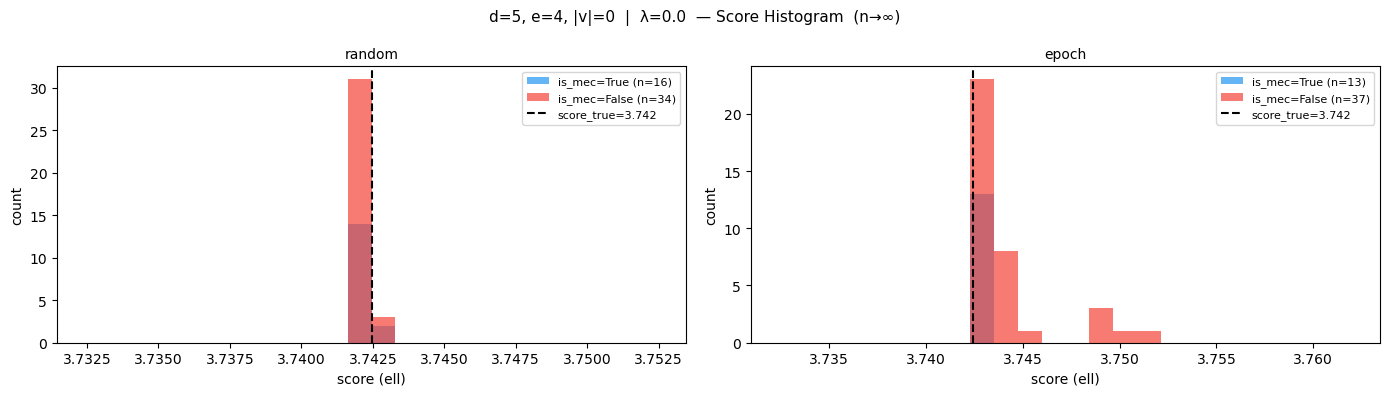

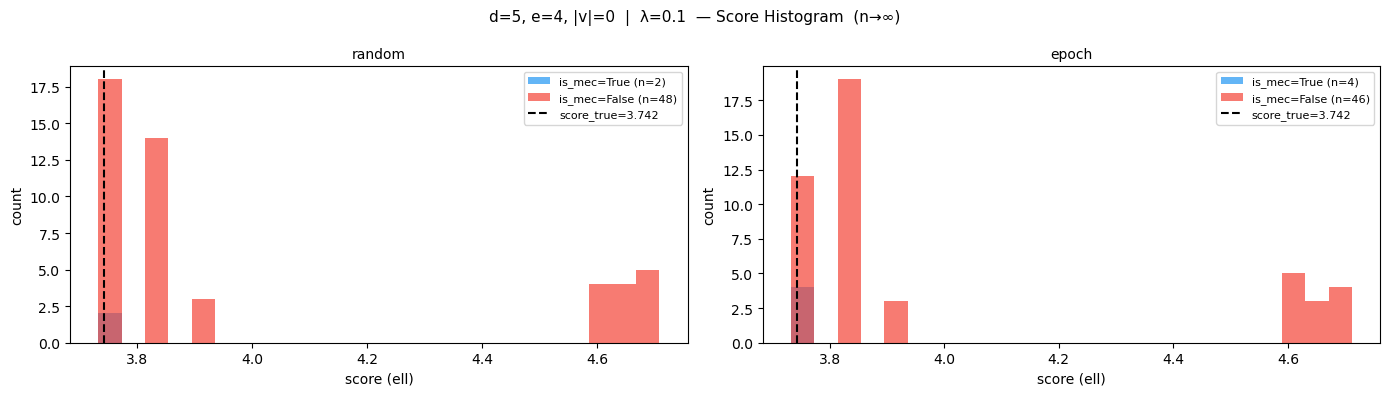

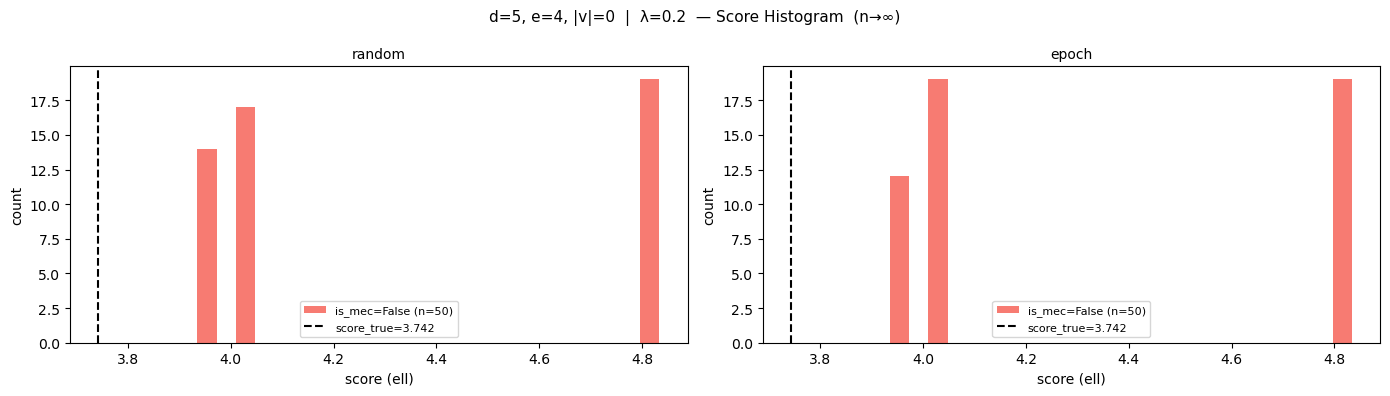

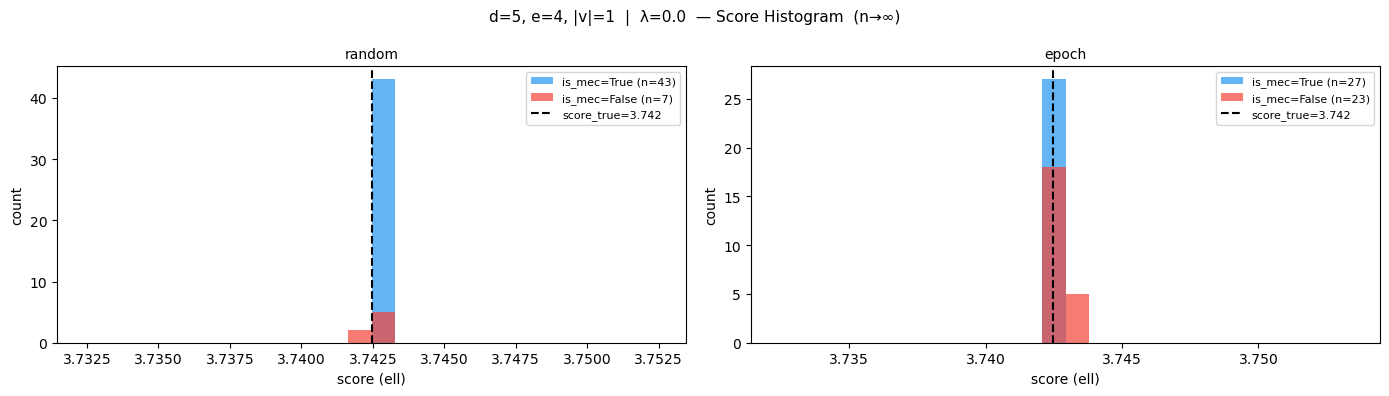

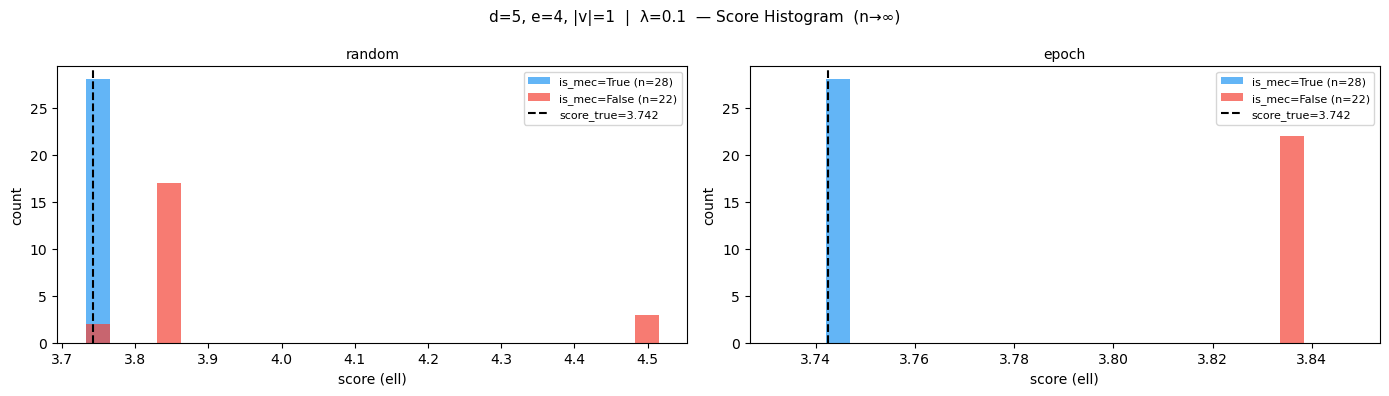

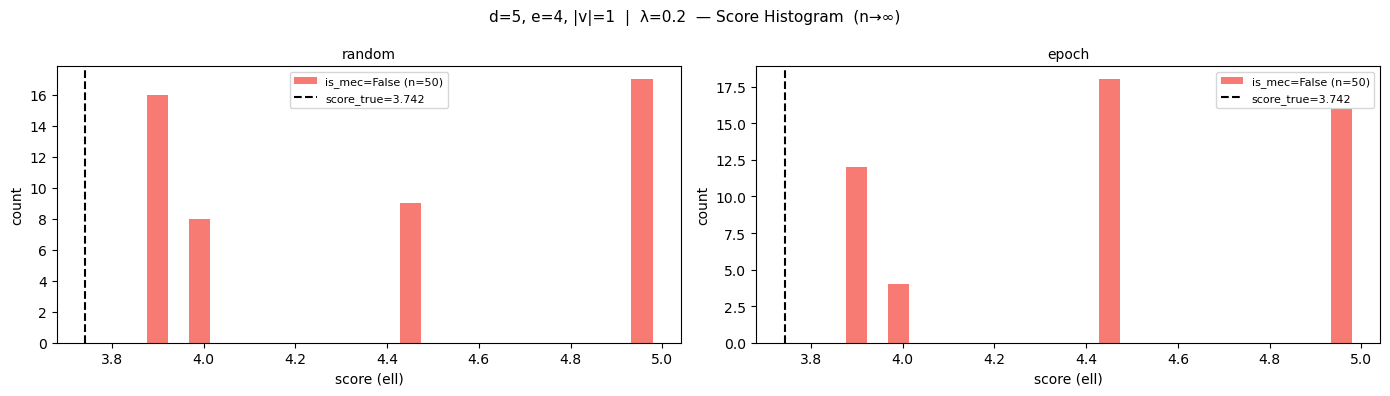

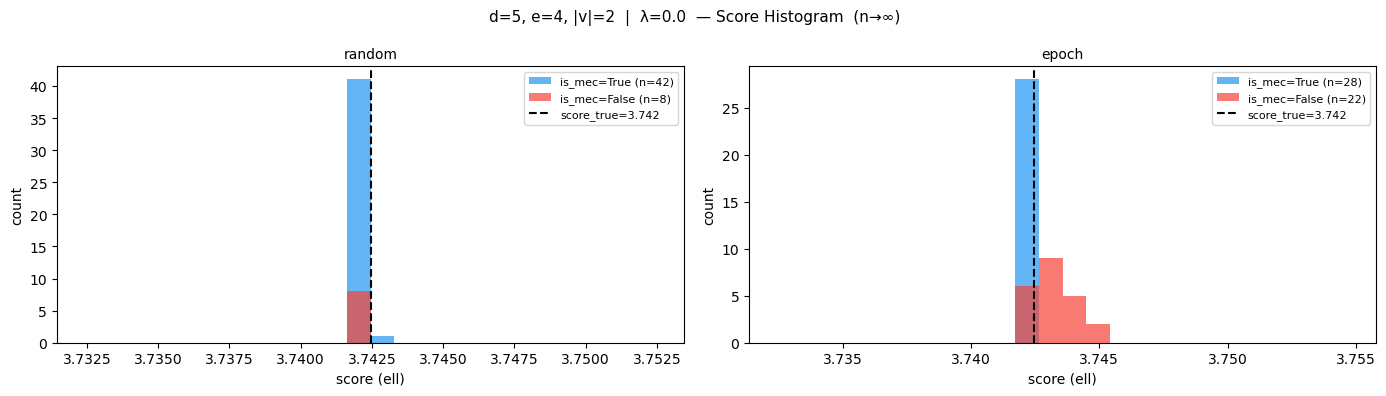

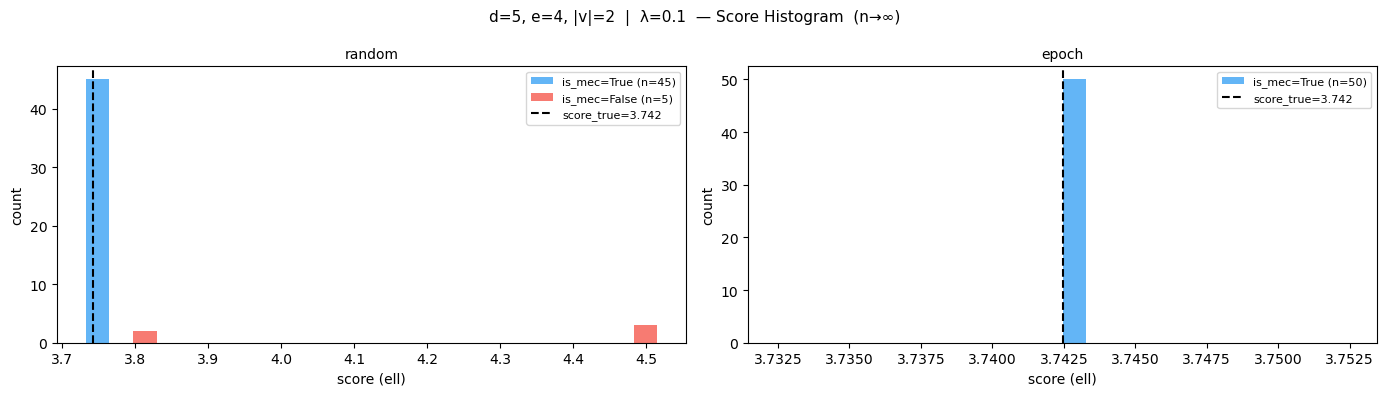

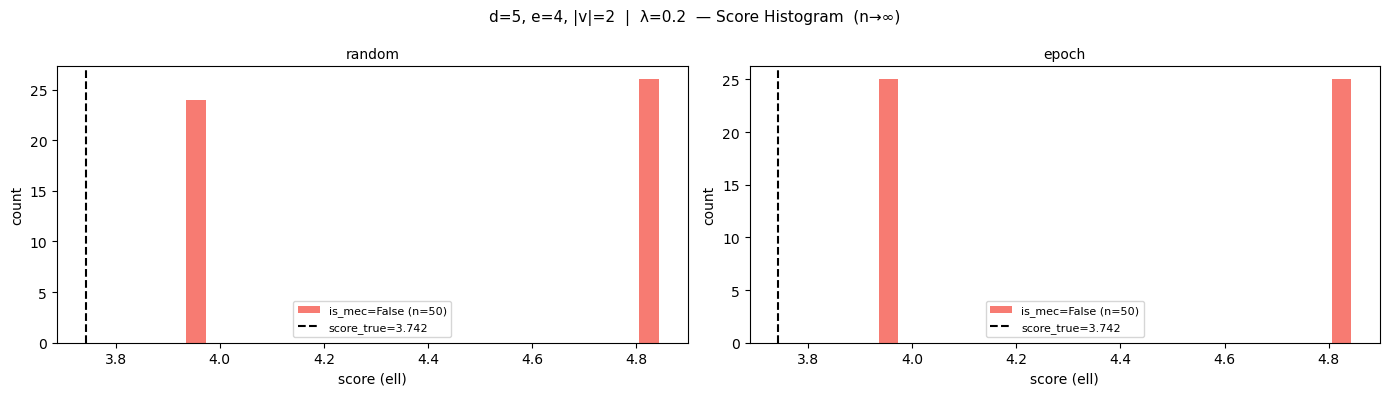

In [24]:
def plot_score_histogram(res: dict, lam: float) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"{res['name']}  |  λ={lam}  — Score Histogram  (n→∞)", fontsize=11)

    for ax, algo in zip(axes, ["random", "epoch"]):
        runs  = res["results"][lam][algo]
        sc_t  = [r["score"] for r in runs if r["is_mec"]]
        sc_f  = [r["score"] for r in runs if not r["is_mec"]]

        bins = np.linspace(
            min([r["score"] for r in runs]) - 0.01,
            max([r["score"] for r in runs]) + 0.01,
            25,
        )
        if sc_t:
            ax.hist(sc_t, bins=bins, color="#2196F3", alpha=0.7, label=f"is_mec=True (n={len(sc_t)})")
        if sc_f:
            ax.hist(sc_f, bins=bins, color="#F44336", alpha=0.7, label=f"is_mec=False (n={len(sc_f)})")
        ax.axvline(res["score_true"], color="black", linestyle="--", linewidth=1.5,
                   label=f"score_true={res['score_true']:.3f}")
        ax.set_title(f"{algo}", fontsize=10)
        ax.set_xlabel("score (ell)")
        ax.set_ylabel("count")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


for res in all_results:
    for lam in LAMBDAS:
        plot_score_histogram(res, lam)

## Analysis: λ 对 MEC rate 的影响（汇总）

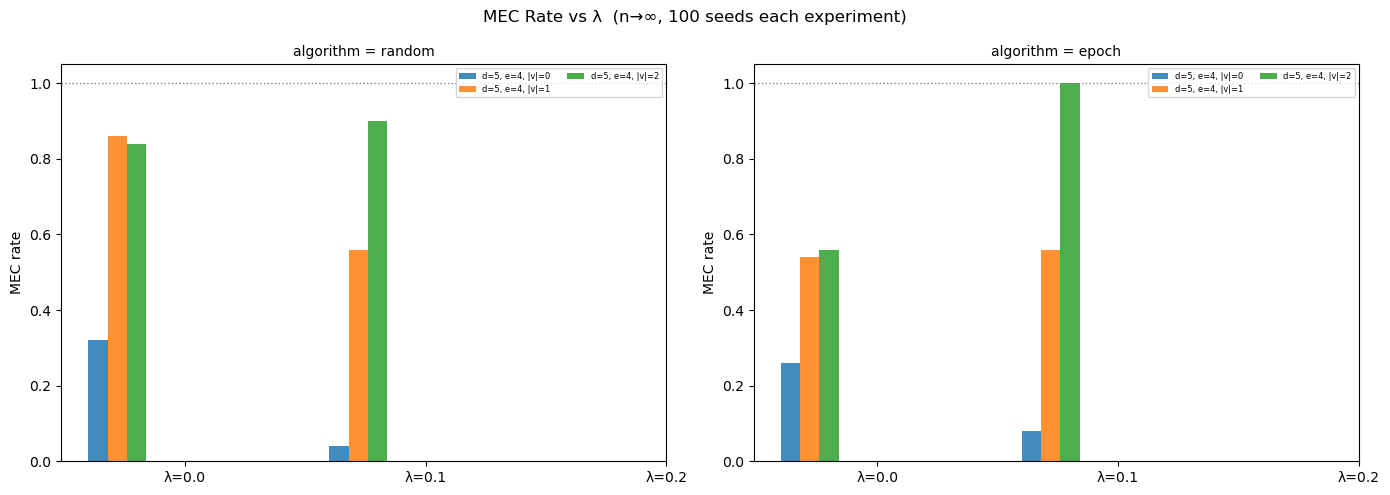

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MEC Rate vs λ  (n→∞, 100 seeds each experiment)", fontsize=12)

x = np.arange(len(LAMBDAS))
width = 0.08
colors = plt.cm.tab10(np.linspace(0, 0.9, len(experiments)))

for ax, algo in zip(axes, ["random", "epoch"]):
    for i, res in enumerate(all_results):
        mec_rates = [
            np.mean([r["is_mec"] for r in res["results"][lam][algo]])
            for lam in LAMBDAS
        ]
        offset = (i - len(experiments) / 2) * width
        ax.bar(x + offset, mec_rates, width=width, color=colors[i],
               label=res["name"], alpha=0.85)

    ax.set_title(f"algorithm = {algo}", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([f"λ={l}" for l in LAMBDAS])
    ax.set_ylabel("MEC rate")
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
    ax.legend(fontsize=6, loc="upper right", ncol=2)

plt.tight_layout()
plt.show()

## Analysis: Score Gap Distribution (score_hat - score_true)

如果算法收敛到真实解，score_gap → 0。
如果出现 local minima，则 score_gap > 0（found a worse solution）或 score_gap < 0（overfitting to population, 不应出现）。

In [26]:
print(f"{'Experiment':<35} {'algo':>6} {'lam':>5}  "
      f"{'gap_mean':>10} {'gap_max':>10} {'gap_std':>10}  "
      f"{'n_gap>0.01':>10}")
print("-" * 100)

for res in all_results:
    for algo in ["random", "epoch"]:
        for lam in LAMBDAS:
            runs = res["results"][lam][algo]
            gaps = np.array([r["score_gap"] for r in runs])
            n_positive = int(np.sum(gaps > 0.01))
            print(f"{res['name']:<35} {algo:>6} {lam:>5.1f}  "
                  f"{gaps.mean():>10.4f} {gaps.max():>10.4f} {gaps.std():>10.4f}  "
                  f"{n_positive:>10}")

Experiment                            algo   lam    gap_mean    gap_max    gap_std  n_gap>0.01
----------------------------------------------------------------------------------------------------
d=5, e=4, |v|=0                     random   0.0      0.0000     0.0000     0.0000           0
d=5, e=4, |v|=0                     random   0.1      0.2785     0.9560     0.3809          39
d=5, e=4, |v|=0                     random   0.2      0.5654     1.0817     0.4055          50
d=5, e=4, |v|=0                      epoch   0.0      0.0012     0.0095     0.0023           0
d=5, e=4, |v|=0                      epoch   0.1      0.2670     0.9589     0.3651          41
d=5, e=4, |v|=0                      epoch   0.2      0.5688     1.0817     0.4028          50
d=5, e=4, |v|=1                     random   0.0      0.0000     0.0000     0.0000           0
d=5, e=4, |v|=1                     random   0.1      0.0783     0.7630     0.1786          20
d=5, e=4, |v|=1                     random  

## 结论

**核心问题回答**：  
- 若 n→∞ 下 `score_gap` 仍然 > 0（即 score > score_true），说明 score ≈ 150 的问题来自**算法 local minima**，而非 sampling noise。  
- 若 `score_gap ≈ 0` 但 `is_mec=False`，说明算法找到了等价 score 的错误结构（MEC 内的非等价图）。
- 若 MEC rate 随 λ 变化，说明正则化确实影响 solution landscape。

**算法对比**：epoch vs random 在 n→∞ 下的差异揭示了迭代顺序对收敛的影响。

---

## 补充实验：n → ∞，100 次随机初始化，Score vs Structure

与上方相同的 3 个实验（d=5, e=4, |v|=0/1/2），重新跑 100 次，专注分析 Score vs Structure。

In [6]:
# ============================================================
#  Run all experiments  (this may take a few minutes)
# ============================================================
LAMBDAS     = [0.0, 0.1, 0.2]
N_REPEATS   = 50
T_RANDOM    = 12500
N_EPOCHS    = 500
THRESHOLD   = 0.05

# 100 次随机初始化，复用 run_experiment_inf
all_results_100 = []
for idx in [6, 7, 8]:
    exp = experiments[idx]
    print(f"Running: {exp['name']} ...", flush=True)
    res = run_experiment_inf(
        exp,
        n_repeats=100,
        lambdas=LAMBDAS,
        T_random=T_RANDOM,
        n_epochs=N_EPOCHS,
        threshold=THRESHOLD,
    )
    all_results_100.append(res)
    for lam in LAMBDAS:
        for algo in ["random", "epoch"]:
            runs = res["results"][lam][algo]
            mec_rate = np.mean([r["is_mec"] for r in runs])
            print(f"  λ={lam}  {algo:6s}: MEC={mec_rate:.2f}")
print("Done.")

Running: d=5, e=4, |v|=0 ...
  λ=0.0  random: MEC=0.30
  λ=0.0  epoch : MEC=0.24
  λ=0.1  random: MEC=0.11
  λ=0.1  epoch : MEC=0.12
  λ=0.2  random: MEC=0.00
  λ=0.2  epoch : MEC=0.00
Running: d=5, e=4, |v|=1 ...
  λ=0.0  random: MEC=0.81
  λ=0.0  epoch : MEC=0.54
  λ=0.1  random: MEC=0.55
  λ=0.1  epoch : MEC=0.60
  λ=0.2  random: MEC=0.00
  λ=0.2  epoch : MEC=0.00
Running: d=5, e=4, |v|=2 ...
  λ=0.0  random: MEC=0.87
  λ=0.0  epoch : MEC=0.60
  λ=0.1  random: MEC=0.91
  λ=0.1  epoch : MEC=1.00
  λ=0.2  random: MEC=0.00
  λ=0.2  epoch : MEC=0.00
Done.


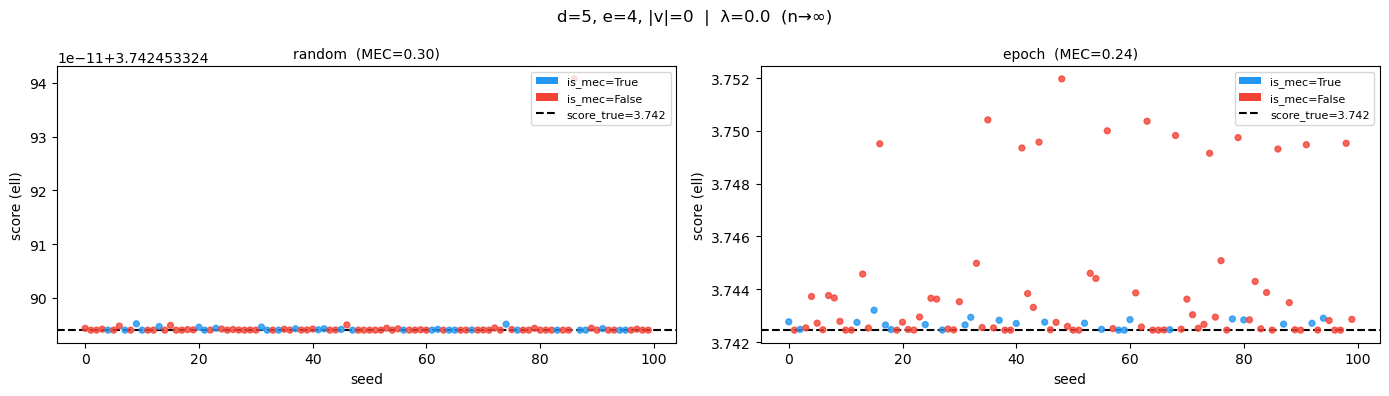

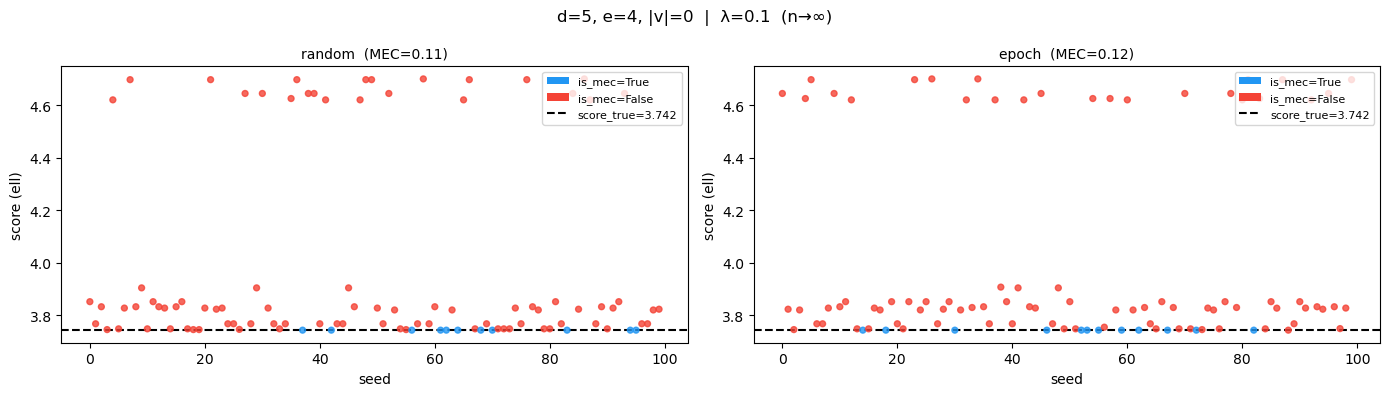

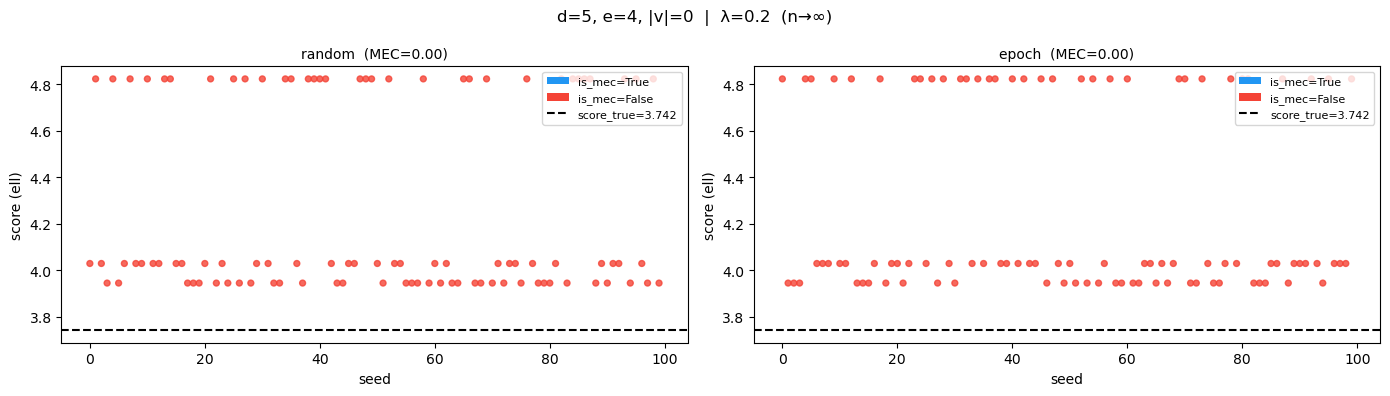

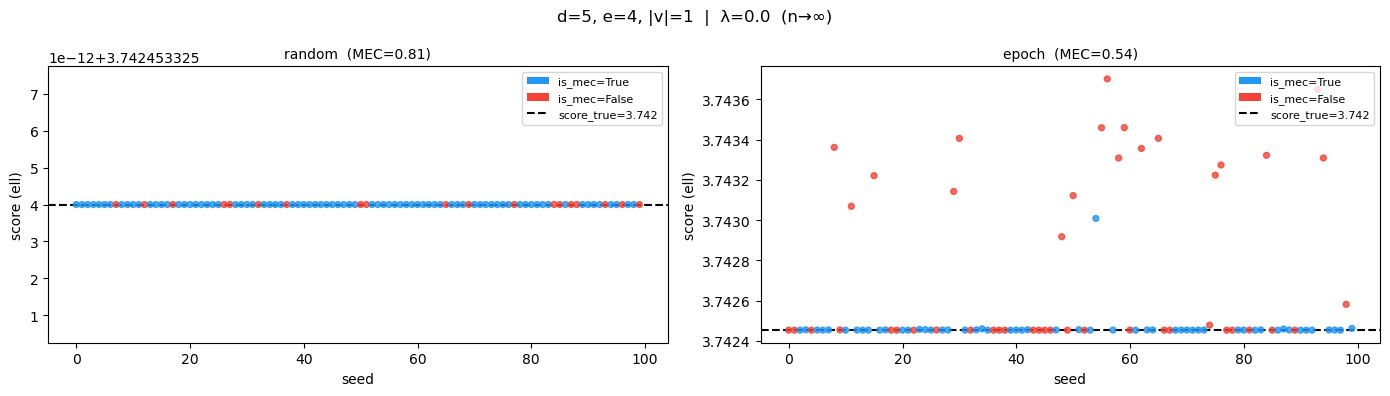

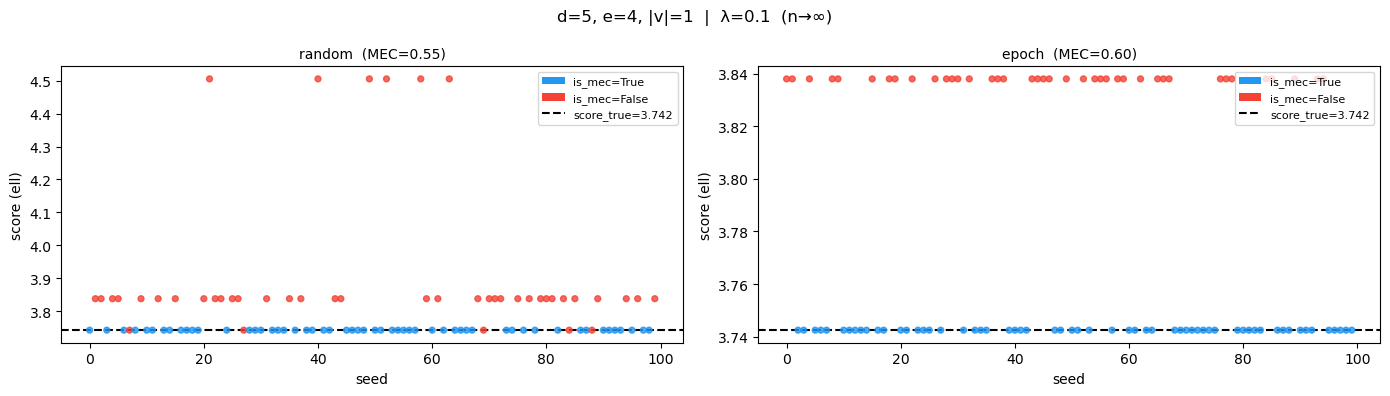

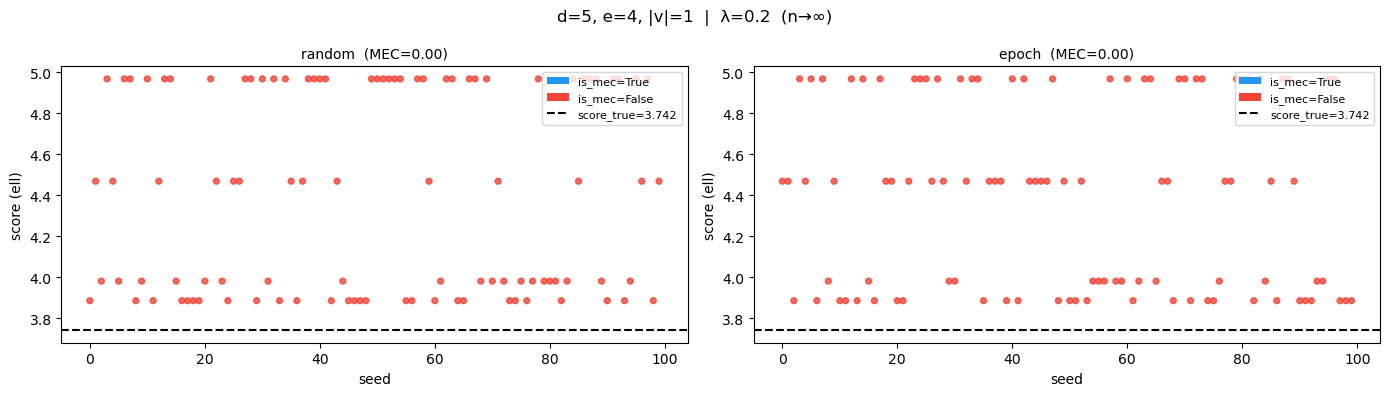

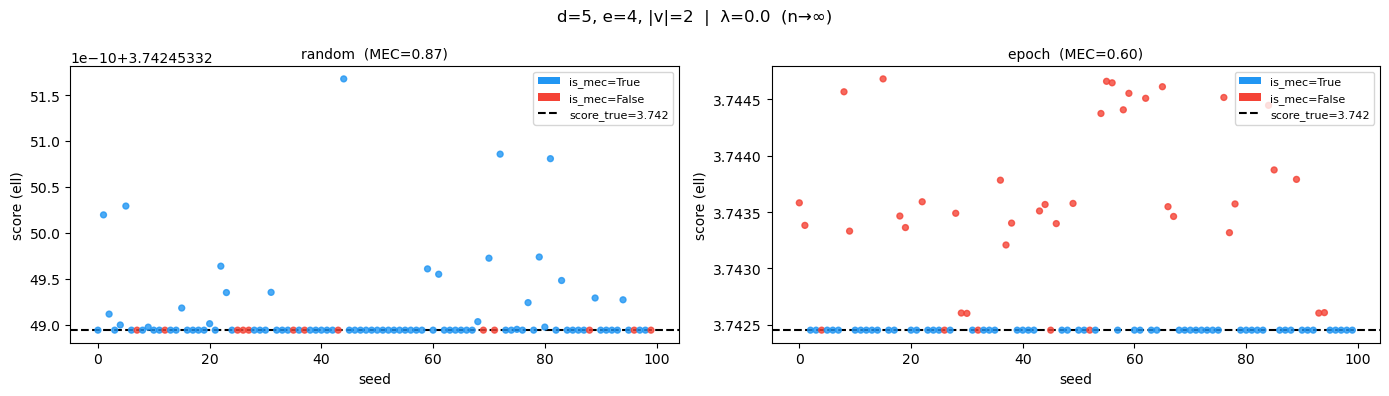

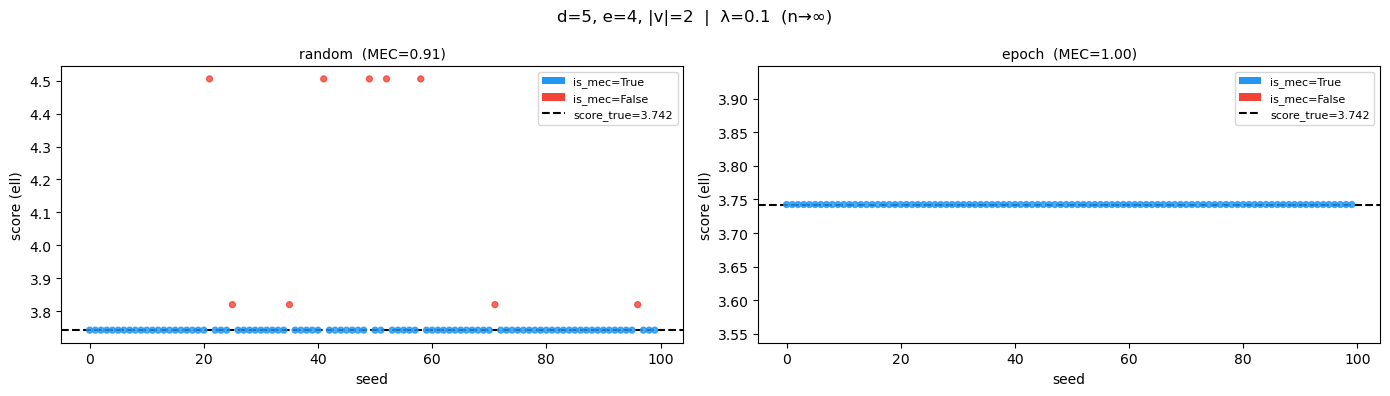

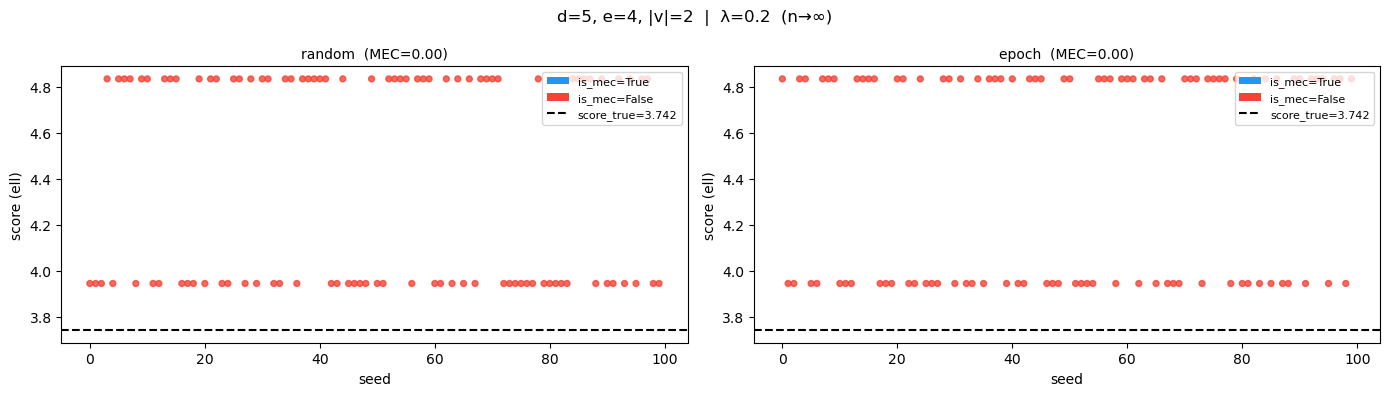

In [9]:
# Score vs Structure — 复用 plot_score_vs_struct
for res in all_results_100:
    for lam in LAMBDAS:
        plot_score_vs_struct(res, lam)